# 07 · Pain phenotypes from Medical Conditions Log

Parse free-text `MHTERM` for pain diagnoses in six buckets: musculoskeletal / neuropathic / dystonic / central / headache / visceral. Cross-tab phenotype × DBS; see whether response (no-worsening) varies by phenotype.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(stringr); library(ggplot2) })

mc <- readr::read_csv(file.path(PROJECT_ROOT, "Medical_Conditions_Log_04Nov2024.csv"),
                      show_col_types = FALSE) %>%
  dplyr::mutate(PATNO = as.integer(PATNO), MHTERM = toupper(MHTERM))
cat("Med-conditions rows:", nrow(mc), "  patients:", dplyr::n_distinct(mc$PATNO), "\n")

Med-conditions rows: 21237   patients: 3283 


In [2]:
# Per-phenotype set of PATNOs with any matching MHTERM
pheno <- purrr::map(PAIN_PHENOTYPE_PATTERNS, function(pats) {
  regex <- toupper(paste(pats, collapse = "|"))
  mc %>% dplyr::filter(!is.na(MHTERM), stringr::str_detect(MHTERM, regex)) %>%
    dplyr::distinct(PATNO) %>% dplyr::pull(PATNO)
})

# Build one-row-per-patient boolean table
all_patnos <- sort(unique(mc$PATNO))
pheno_df <- tibble::tibble(PATNO = all_patnos)
for (nm in names(pheno)) pheno_df[[nm]] <- pheno_df$PATNO %in% pheno[[nm]]

n_summ <- pheno_df %>% dplyr::summarise(dplyr::across(-PATNO, sum)) %>%
  tidyr::pivot_longer(dplyr::everything(), names_to = "phenotype", values_to = "n")
print(n_summ)
save_table(n_summ, "pain_phenotype_counts")
save_object(pheno_df, "pain_phenotype_flags")

# A tibble: 6 × 2
  phenotype           n
  <chr>           <int>
1 musculoskeletal   957
2 neuropathic       309
3 dystonic           69
4 central            41
5 headache          221
6 visceral          111


In [3]:
delta <- readRDS(file.path(OUT_OBJ, "pain_delta_responder.rds")) %>%
  dplyr::mutate(no_worsening = as.integer(delta < 1))
dat <- delta %>% dplyr::left_join(pheno_df, by = "PATNO") %>%
  dplyr::mutate(dplyr::across(dplyr::any_of(names(PAIN_PHENOTYPE_PATTERNS)),
                              ~ dplyr::coalesce(.x, FALSE)))
print(dplyr::count(dat, will_receive_dbs, name = "n"))

summ <- purrr::map_dfr(names(PAIN_PHENOTYPE_PATTERNS), function(ph) {
  d <- dat %>% dplyr::filter(.data[[ph]])
  if (nrow(d) == 0) return(tibble::tibble(phenotype = ph, will_receive_dbs = NA,
                                          n = 0L, mean_delta = NA, pct_no_worse = NA))
  d %>% dplyr::group_by(will_receive_dbs) %>%
    dplyr::summarise(n = dplyr::n(),
                     mean_delta = mean(delta),
                     pct_no_worse = mean(no_worsening), .groups = "drop") %>%
    dplyr::mutate(phenotype = ph, .before = 1)
})
print(summ)
save_table(summ, "pain_phenotype_by_arm_delta")

# A tibble: 2 × 2
  will_receive_dbs     n
  <lgl>            <int>
1 FALSE               34
2 TRUE                40


# A tibble: 10 × 5
   phenotype       will_receive_dbs     n mean_delta pct_no_worse
   <chr>           <lgl>            <int>      <dbl>        <dbl>
 1 musculoskeletal FALSE                9      0.628        0.667
 2 musculoskeletal TRUE                17      0.112        0.765
 3 neuropathic     FALSE                2      1.43         0    
 4 neuropathic     TRUE                 6      0.442        0.667
 5 dystonic        FALSE                4      0.446        0.5  
 6 dystonic        TRUE                 2     -0.217        1    
 7 central         NA                   0     NA           NA    
 8 headache        FALSE                1     -1            1    
 9 headache        TRUE                 4     -0.838        1    
10 visceral        TRUE                 2     -0.933        1    


In [4]:
fisher_by_pheno <- purrr::map_dfr(names(PAIN_PHENOTYPE_PATTERNS), function(ph) {
  d <- dat %>% dplyr::filter(.data[[ph]])
  if (nrow(d) < 10) return(tibble::tibble(phenotype = ph, n = nrow(d), or = NA, p = NA))
  tab <- table(d$will_receive_dbs, d$no_worsening)
  if (any(dim(tab) < 2)) return(tibble::tibble(phenotype = ph, n = nrow(d), or = NA, p = NA))
  f <- stats::fisher.test(tab)
  tibble::tibble(phenotype = ph, n = nrow(d), or = as.numeric(f$estimate), p = f$p.value)
})
print(fisher_by_pheno)
save_table(fisher_by_pheno, "pain_phenotype_fisher")

# A tibble: 6 × 4
  phenotype           n    or      p
  <chr>           <int> <dbl>  <dbl>
1 musculoskeletal    26  1.59  0.661
2 neuropathic         8 NA    NA    
3 dystonic            6 NA    NA    
4 central             0 NA    NA    
5 headache            5 NA    NA    
6 visceral            2 NA    NA    


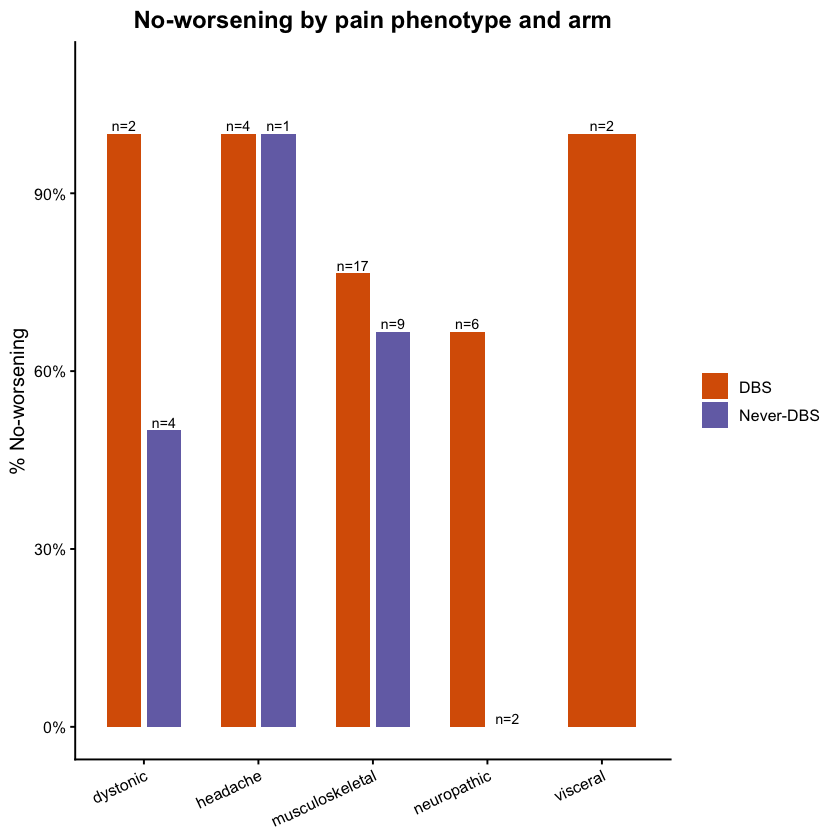

In [5]:
pl <- summ %>% dplyr::filter(!is.na(will_receive_dbs)) %>%
  dplyr::mutate(arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))
p_phe <- ggplot(pl, aes(x = phenotype, y = pct_no_worse, fill = arm)) +
  geom_col(position = position_dodge(0.7), width = 0.6) +
  geom_text(aes(label = sprintf("n=%d", n)), position = position_dodge(0.7), vjust = -0.3, size = 3) +
  scale_y_continuous("% No-worsening", labels = scales::percent_format(), limits = c(0, 1.1)) +
  scale_fill_manual(values = c(`DBS`="#d95f02", `Never-DBS`="#7570b3"), name = NULL) +
  labs(title = "No-worsening by pain phenotype and arm", x = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 25, hjust = 1))
p_phe
save_fig(p_phe, "Fig15_pain_phenotype_no_worse", width = 8, height = 4.4)